In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, 
                             classification_report,
                             RocCurveDisplay)

In [2]:
df=pd.read_csv('Loan_Data.csv')
df.shape

(10000, 8)

In [3]:
df.head(10)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
5,4661159,0,5376.886873,7189.121298,85529.84591,2,697,0
6,8291909,1,3634.057471,7085.980095,68691.57707,6,722,0
7,4616950,4,3302.172238,13067.570210,50352.16821,3,545,1
8,3395789,0,2938.325123,1918.404472,53497.37754,4,676,0
9,4045948,0,5396.366774,5298.824524,92349.55399,2,447,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [5]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [6]:
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Task 3 → Credit Risk / Default Model

In [8]:
print("Default Rate:", df['default'].mean() * 100, "%")

Default Rate: 18.509999999999998 %


In [9]:
df = df.drop(columns=['customer_id'])

# Features (X) and Target (y)
X = df.drop(columns=['default'])
y = df['default']
print("Features used:", X.columns.tolist())

Features used: ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 8000
Testing samples  : 2000


In [11]:
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

In [12]:
model = LogisticRegression(random_state=42)
model.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [13]:
rf_model = RandomForestClassifier(
n_estimators = 100,
    random_state = 42
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
# Logistic Regression predictions
lr_pred      = model.predict(X_test_sc)
lr_pred_prob = model.predict_proba(X_test_sc)[:, 1]

# Random Forest predictions
rf_pred      = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]

print("MODEL COMPARISON")
print("Logistic Regression")
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC : {roc_auc_score(y_test, lr_pred_prob):.4f}")
print("\nRandom Forest")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC : {roc_auc_score(y_test, rf_pred_prob):.4f}")

MODEL COMPARISON
Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC : 1.0000

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.98       348

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC : 0.9997


c:\Users\Manju\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Manju\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


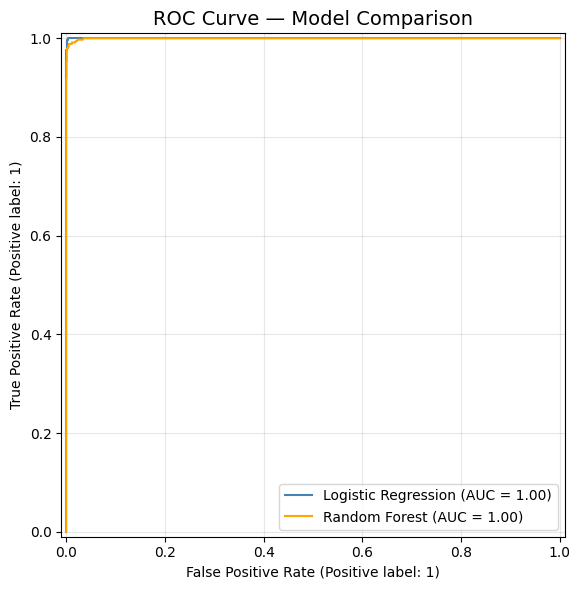

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot both curves
RocCurveDisplay.from_estimator(
    model, X_test_sc, y_test,
    ax    = ax,
    name  = 'Logistic Regression',
    color = 'steelblue'
)

RocCurveDisplay.from_estimator(
    rf_model, X_test, y_test,
    ax    = ax,
    name  = 'Random Forest',
    color = 'orange'
)

plt.title('ROC Curve — Model Comparison', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

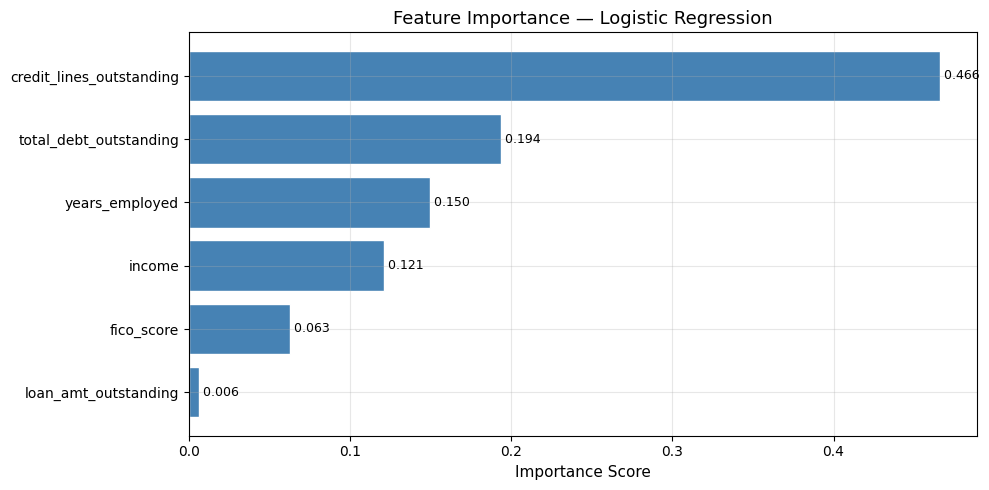


Logistic Regression Feature Importance
Feature                          LR Score
credit_lines_outstanding           0.4659
total_debt_outstanding             0.1938
years_employed                     0.1499
income                             0.1212
fico_score                         0.0627
loan_amt_outstanding               0.0065


In [16]:
lr_importance = pd.DataFrame({
    'Feature'  : X.columns,
    'LR_Score' : np.abs(model.coef_[0])
}).sort_values('LR_Score', ascending=True)

lr_importance['LR_Score'] = (lr_importance['LR_Score'] / 
                              lr_importance['LR_Score'].sum())

plt.figure(figsize=(10, 5))
plt.barh(lr_importance['Feature'],
         lr_importance['LR_Score'],
         color='steelblue',
         edgecolor='white')
plt.xlabel('Importance Score', fontsize=11)
plt.title('Feature Importance — Logistic Regression', fontsize=13)
plt.grid(True, alpha=0.3)
for i, v in enumerate(lr_importance['LR_Score']):
    plt.text(v, i, f' {v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nLogistic Regression Feature Importance")
print(f"{'Feature':<30} {'LR Score':>10}")
for _, row in lr_importance.sort_values(
                'LR_Score', ascending=False).iterrows():
    print(f"{row['Feature']:<30} {row['LR_Score']:>10.4f}")

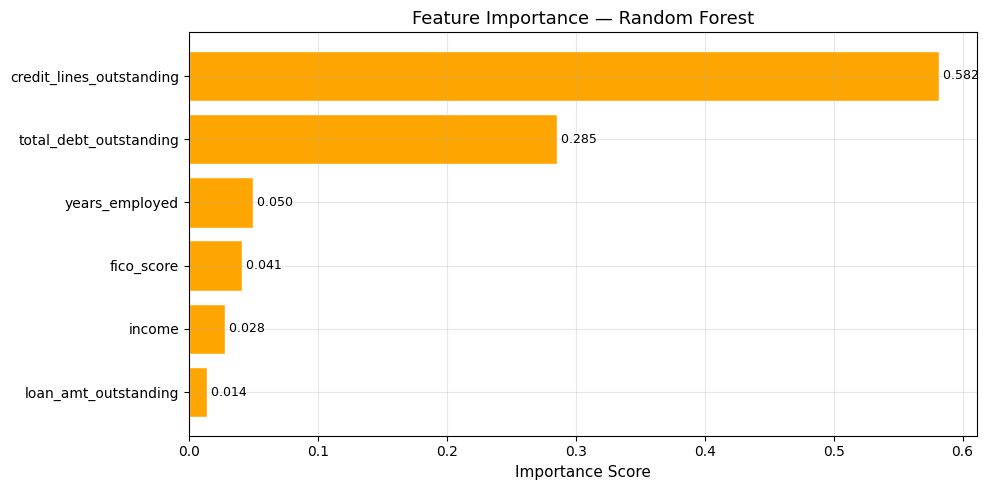


Random Forest Feature Importance
Feature                          RF Score
credit_lines_outstanding           0.5821
total_debt_outstanding             0.2851
years_employed                     0.0498
fico_score                         0.0411
income                             0.0277
loan_amt_outstanding               0.0141


In [17]:
rf_importance = pd.DataFrame({
    'Feature'  : X.columns,
    'RF_Score' : rf_model.feature_importances_
}).sort_values('RF_Score', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(rf_importance['Feature'],
         rf_importance['RF_Score'],
         color='orange',
         edgecolor='white')
plt.xlabel('Importance Score', fontsize=11)
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.grid(True, alpha=0.3)
for i, v in enumerate(rf_importance['RF_Score']):
    plt.text(v, i, f' {v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nRandom Forest Feature Importance")
print(f"{'Feature':<30} {'RF Score':>10}")
for _, row in rf_importance.sort_values(
                'RF_Score', ascending=False).iterrows():
    print(f"{row['Feature']:<30} {row['RF_Score']:>10.4f}")

In [18]:
def predict_pd(credit_lines_outstanding,
               loan_amt_outstanding,
               total_debt_outstanding,
               income,
               years_employed,
               fico_score):
  
    # Create input dataframe
    borrower = pd.DataFrame([{
        'credit_lines_outstanding' : credit_lines_outstanding,
        'loan_amt_outstanding'     : loan_amt_outstanding,
        'total_debt_outstanding'   : total_debt_outstanding,
        'income'                   : income,
        'years_employed'           : years_employed,
        'fico_score'               : fico_score
    }])

    # Scale input using same scaler
    borrower_scaled = scaler.transform(borrower)

    # Predict probability
    pd_score = model.predict_proba(borrower_scaled)[0][1]

    return round(pd_score, 4)

In [19]:
def expected_loss(credit_lines_outstanding,
                  loan_amt_outstanding,
                  total_debt_outstanding,
                  income,
                  years_employed,
                  fico_score,
                  recovery_rate=0.10):
    
    # Get PD from model
    pd_score = predict_pd(
        credit_lines_outstanding,
        loan_amt_outstanding,
        total_debt_outstanding,
        income,
        years_employed,
        fico_score
    )

    # Calculate components
    lgd  = 1 - recovery_rate          # Loss Given Default = 90%
    ead  = loan_amt_outstanding        # Exposure at Default

    # Expected Loss Formula
    el = pd_score * lgd * ead

    print(f"\n--- Expected Loss Report ---")
    print(f"PD  (Prob of Default)  : {pd_score*100:.2f}%")
    print(f"LGD (Loss Given Deflt) : {lgd*100:.0f}%")
    print(f"EAD (Loan Amount)      : ${ead:,.2f}")
    print(f"Expected Loss          : ${el:,.2f}")

    return round(el, 2)


In [20]:
def expected_loss_rf(credit_lines_outstanding,
                     loan_amt_outstanding,
                     total_debt_outstanding,
                     income,
                     years_employed,
                     fico_score,
                     recovery_rate=0.10):
  
    borrower = pd.DataFrame([{
        'credit_lines_outstanding' : credit_lines_outstanding,
        'loan_amt_outstanding'     : loan_amt_outstanding,
        'total_debt_outstanding'   : total_debt_outstanding,
        'income'                   : income,
        'years_employed'           : years_employed,
        'fico_score'               : fico_score
    }])

    # Random Forest doesn't need scaling
    pd_score = rf_model.predict_proba(borrower)[0][1]

    lgd = 1 - recovery_rate
    ead = loan_amt_outstanding
    el  = pd_score * lgd * ead

    print(f"\n Expected Loss Report (Random Forest)")
    print(f"PD  (Prob of Default)  : {pd_score*100:.2f}%")
    print(f"LGD (Loss Given Deflt) : {lgd*100:.0f}%")
    print(f"EAD (Loan Amount)      : ${ead:,.2f}")
    print(f"Expected Loss          : ${el:,.2f}")

    return round(el, 2)

In [21]:
test_samples        = X_test.iloc[:10].copy()
test_actual         = y_test.iloc[:10].copy()
# ---- Logistic Regression Predictions ----
test_samples_scaled = scaler.transform(test_samples)
lr_pd               = model.predict_proba(test_samples_scaled)[:, 1]
lr_pred             = model.predict(test_samples_scaled)
# ---- Random Forest Predictions ----
rf_pd               = rf_model.predict_proba(test_samples)[:, 1]
rf_pred             = rf_model.predict(test_samples)


results = test_samples[['income',
                         'fico_score',
                         'loan_amt_outstanding']].copy()
results['actual_default']    = test_actual.values
# Logistic Regression columns
results['LR_predicted']      = lr_pred
results['LR_PD_%']           = (lr_pd * 100).round(2)
results['LR_loss_$']         = (lr_pd * 0.90 * 
                                results['loan_amt_outstanding']
                                ).round(2)
results['LR_correct?']       = (results['actual_default'] == 
                                results['LR_predicted'])
# Random Forest columns
results['RF_predicted']      = rf_pred
results['RF_PD_%']           = (rf_pd * 100).round(2)
results['RF_loss_$']         = (rf_pd * 0.90 * 
                                results['loan_amt_outstanding']
                                ).round(2)
results['RF_correct?']       = (results['actual_default'] == 
                                results['RF_predicted'])


print("\nLOGISTIC REGRESSION — TEST SAMPLE PREDICTIONS")
print(results[[
    'income',
    'fico_score',
    'loan_amt_outstanding',
    'actual_default',
    'LR_predicted',
    'LR_PD_%',
    'LR_loss_$',
    'LR_correct?'
]].to_string())

lr_correct = results['LR_correct?'].sum()
print(f"\nCorrect Predictions : {lr_correct}/10")
print(f"Accuracy            : {lr_correct*10}%")
print(f"Total Expected Loss : ${results['LR_loss_$'].sum():,.2f}")
print(f"Avg PD              : {results['LR_PD_%'].mean():.2f}%")



print("\nRANDOM FOREST — TEST SAMPLE PREDICTIONS")
print(results[[
    'income',
    'fico_score',
    'loan_amt_outstanding',
    'actual_default',
    'RF_predicted',
    'RF_PD_%',
    'RF_loss_$',
    'RF_correct?'
]].to_string())

rf_correct = results['RF_correct?'].sum()
print(f"\nCorrect Predictions : {rf_correct}/10")
print(f"Accuracy            : {rf_correct*10}%")
print(f"Total Expected Loss : ${results['RF_loss_$'].sum():,.2f}")
print(f"Avg PD              : {results['RF_PD_%'].mean():.2f}%")


print("\nFINAL MODEL COMPARISON SUMMARY")
print(f"{'Metric':<25} {'Log. Reg':>10} {'Ran. Forest':>12}")
print(f"{'Correct Predictions':<25} {lr_correct}/10 {rf_correct}/10".rjust(10))
print(f"{'Accuracy':<25} {lr_correct*10:>9}% {rf_correct*10:>10}%")
print(f"{'Avg PD':<25} "
      f"{results['LR_PD_%'].mean():>9.2f}% "
      f"{results['RF_PD_%'].mean():>10.2f}%")
print(f"{'Total Expected Loss':<25} "
      f"${results['LR_loss_$'].sum():>9,.2f} "
      f"${results['RF_loss_$'].sum():>9,.2f}")



LOGISTIC REGRESSION — TEST SAMPLE PREDICTIONS
           income  fico_score  loan_amt_outstanding  actual_default  LR_predicted  LR_PD_%  LR_loss_$  LR_correct?
6252  72005.83951         593           3584.844437               0             0     0.00       0.00         True
4684  80431.47019         634           5821.006507               0             0     0.81      42.17         True
1731  86303.95374         607           5343.193215               1             1   100.00    4808.87         True
4742  28621.64224         621           1468.268561               0             0     0.00       0.00         True
4521  69844.46479         650           3519.975193               0             0     0.00       0.00         True
6340  40744.98376         628           3333.343428               0             0     0.00       0.00         True
576   73335.88904         676           4795.717975               0             0     0.00       0.00         True
5202  58324.23479         710    

In [ ]:
# Task 4 → FICO Score Bucketing 

In [24]:
fico_data = df[['fico_score', 'default']].copy()
fico_data = fico_data.sort_values('fico_score').reset_index(drop=True)
fico_data.shape

(10000, 2)

In [25]:
fico_data.head()

,fico_score,default
0,408,0
1,409,1
2,418,1
3,425,1
4,438,1


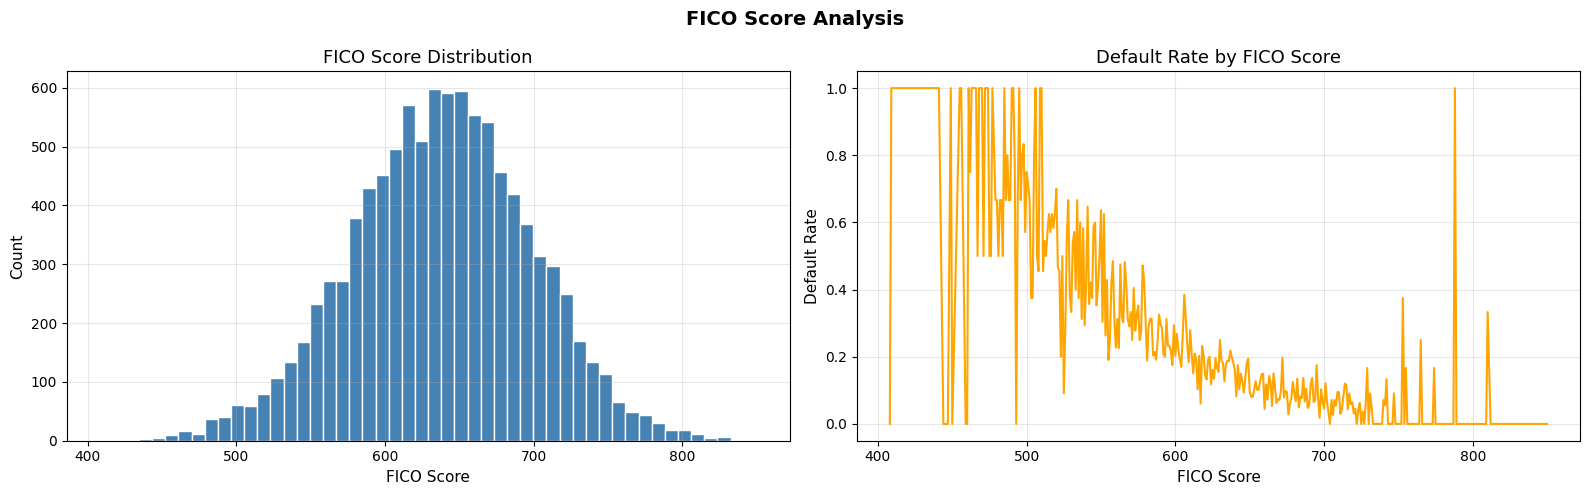

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# FICO Score Distribution
axes[0].hist(fico_data['fico_score'],
             bins     = 50,
             color    = 'steelblue',
             edgecolor= 'white')
axes[0].set_xlabel('FICO Score', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('FICO Score Distribution', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Default Rate by FICO Score
fico_grouped = fico_data.groupby('fico_score')['default'].mean()
axes[1].plot(fico_grouped.index,
             fico_grouped.values,
             color    = 'orange',
             linewidth= 1.5)
axes[1].set_xlabel('FICO Score', fontsize=11)
axes[1].set_ylabel('Default Rate', fontsize=11)
axes[1].set_title('Default Rate by FICO Score', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.suptitle('FICO Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
def mse_bucketing(fico_scores, n_buckets):
    scores     = np.sort(fico_scores)
    n          = len(scores)
    bucket_size= n // n_buckets
    boundaries = [scores[0]]

    for i in range(1, n_buckets):
        idx = i * bucket_size
        boundaries.append(scores[idx])

    boundaries.append(scores[-1] + 1)
    return boundaries

mse_boundaries = mse_bucketing(
    fico_data['fico_score'].values,
    n_buckets = 5
)

print("\nMSE Bucket Boundaries")
print(mse_boundaries)


MSE Bucket Boundaries
[np.int64(408), np.int64(587), np.int64(623), np.int64(653), np.int64(688), np.int64(851)]


In [ ]:
def log_likelihood(n, k):
    if n == 0 or k == 0 or k == n:
        return 0
    p = k / n
    return k * np.log(p) + (n - k) * np.log(1 - p)


def dp_bucketing(fico_data, n_buckets):
    scores   = np.sort(fico_data['fico_score'].unique())
    n_scores = len(scores)
    score_to_idx = {s: i for i, s in enumerate(scores)}
    cum_n = np.zeros(n_scores + 1)  # cumulative count
    cum_k = np.zeros(n_scores + 1)  # cumulative defaults

    for i, score in enumerate(scores):
        bucket_data = fico_data[fico_data['fico_score'] == score]
        cum_n[i+1]  = cum_n[i] + len(bucket_data)
        cum_k[i+1]  = cum_k[i] + bucket_data['default'].sum()

    def get_ll(i, j):
        n = cum_n[j] - cum_n[i]
        k = cum_k[j] - cum_k[i]
        return log_likelihood(n, k)

    dp   = np.full((n_scores + 1, n_buckets + 1), -np.inf)
    split= np.zeros((n_scores + 1, n_buckets + 1), dtype=int)
    dp[0][0] = 0

    for b in range(1, n_buckets + 1):
        for i in range(b, n_scores + 1):
            for j in range(b-1, i):
                val = dp[j][b-1] + get_ll(j, i)
                if val > dp[i][b]:
                    dp[i][b]   = val
                    split[i][b]= j

    boundaries = []
    i = n_scores
    b = n_buckets

    while b > 0:
        j = split[i][b]
        boundaries.append(scores[j])
        i = j
        b -= 1

    boundaries = sorted(boundaries)
    boundaries.append(scores[-1] + 1)
    return boundaries


ll_boundaries = dp_bucketing(fico_data, n_buckets=5)

print("\nLog Likelihood Bucket Boundaries ")
print(ll_boundaries)


Log Likelihood Bucket Boundaries 
[np.int64(408), np.int64(521), np.int64(581), np.int64(641), np.int64(697), np.int64(851)]


In [31]:
def create_rating_map(boundaries, method_name):
    ratings = {}
    n       = len(boundaries) - 1
    print(f"\nRating Map ({method_name}) ")
    print(f"{'Rating':<10} {'FICO Range':<20} {'Risk Level':<15}")

    risk_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    for i in range(n):
        low  = boundaries[i]
        high = boundaries[i+1]
        # Lower rating = better score (reverse order)
        rating = i + 1
        risk   = risk_labels[i]
        ratings[rating] = (low, high)
        print(f"{rating:<10} {str(int(low))+'-'+str(int(high)):<20} {risk:<15}")
    return ratings


def get_rating(fico_score, boundaries):
    for i in range(len(boundaries) - 1):
        if boundaries[i] <= fico_score < boundaries[i+1]:
            return i + 1
    return len(boundaries) - 1


# Create rating maps for both methods
mse_ratings = create_rating_map(mse_boundaries, 'MSE')
ll_ratings  = create_rating_map(ll_boundaries,  'Log Likelihood')


Rating Map (MSE) 
Rating     FICO Range           Risk Level     
1          408-587              Very Low       
2          587-623              Low            
3          623-653              Medium         
4          653-688              High           
5          688-851              Very High      

Rating Map (Log Likelihood) 
Rating     FICO Range           Risk Level     
1          408-521              Very Low       
2          521-581              Low            
3          581-641              Medium         
4          641-697              High           
5          697-851              Very High      


In [32]:
fico_data['mse_rating'] = fico_data['fico_score'].apply(
    lambda x: get_rating(x, mse_boundaries)
)

# Apply Log Likelihood ratings
fico_data['ll_rating'] = fico_data['fico_score'].apply(
    lambda x: get_rating(x, ll_boundaries)
)

print("\nSample Rating Output")
print(fico_data.head(10))


Sample Rating Output
   fico_score  default  mse_rating  ll_rating
0         408        0           1          1
1         409        1           1          1
2         418        1           1          1
3         425        1           1          1
4         438        1           1          1
5         440        1           1          1
6         441        1           1          1
7         444        0           1          1
8         447        0           1          1
9         449        1           1          1


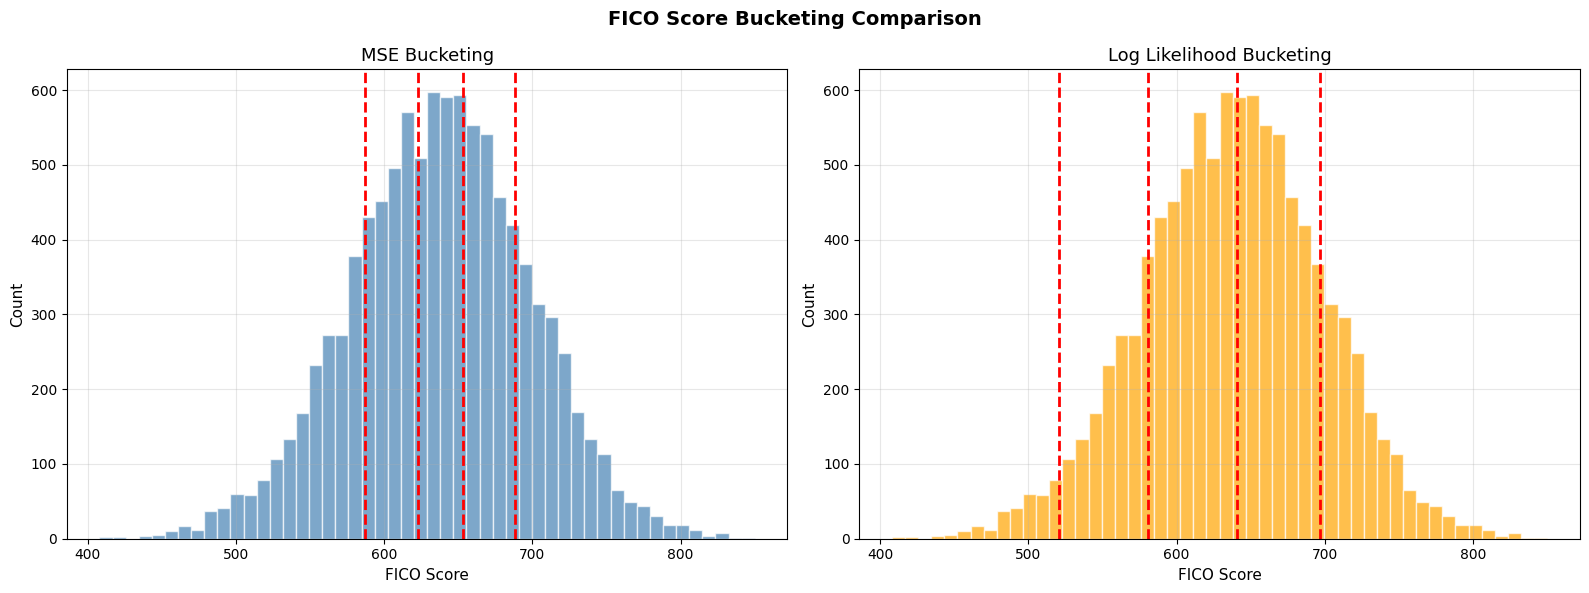

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MSE Bucketing
axes[0].hist(fico_data['fico_score'],
             bins=50, color='steelblue',
             edgecolor='white', alpha=0.7)
for b in mse_boundaries[1:-1]:
    axes[0].axvline(x=b, color='red',
                    linestyle='--', linewidth=2)
axes[0].set_xlabel('FICO Score', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('MSE Bucketing', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Log Likelihood Bucketing
axes[1].hist(fico_data['fico_score'],
             bins=50, color='orange',
             edgecolor='white', alpha=0.7)
for b in ll_boundaries[1:-1]:
    axes[1].axvline(x=b, color='red',
                    linestyle='--', linewidth=2)
axes[1].set_xlabel('FICO Score', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Log Likelihood Bucketing', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.suptitle('FICO Score Bucketing Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
print("\n Default Rate Per Bucket (MSE) ")
print(fico_data.groupby('mse_rating')['default'].agg(
    ['count', 'sum', 'mean']
).rename(columns={
    'count': 'Total',
    'sum'  : 'Defaults',
    'mean' : 'Default Rate'
}))

print("\n Default Rate Per Bucket (Log Likelihood) ")
print(fico_data.groupby('ll_rating')['default'].agg(
    ['count', 'sum', 'mean']
).rename(columns={
    'count': 'Total',
    'sum'  : 'Defaults',
    'mean' : 'Default Rate'
}))


 Default Rate Per Bucket (MSE) 
            Total  Defaults  Default Rate
mse_rating                               
1            1982       804      0.405651
2            1979       426      0.215260
3            1970       305      0.154822
4            2019       202      0.100050
5            2050       114      0.055610

 Default Rate Per Bucket (Log Likelihood) 
           Total  Defaults  Default Rate
ll_rating                               
1            301       199      0.661130
2           1407       536      0.380952
3           3438       703      0.204479
4           3197       336      0.105099
5           1657        77      0.046470
